# World Cup Effect -- does football sink the stock market?
### 19 FIFA World Cups * S&P 500 daily data * macro confounds, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Confirmed%3F: Mixed](https://img.shields.io/badge/Confirmed%3F-Mixed-8b949e?style=flat-square)

Every four years a piece of Wall Street wisdom resurfaces: the World Cup is bad for stock markets. The story goes that fans are distracted, investment managers stop trading, and national anxiety over eliminations drags equity markets lower. Financial economists have written papers about it. But when you put all 19 World Cups on a chart and look at what was actually happening during those summer weeks, the story becomes a lot less tidy.

> **This is the plain-language layer.** Want the t-statistics, permutation distribution, and per-edition breakdown? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from world_cup_effect import data, strategy as st

_CACHE = os.path.abspath(os.path.join("..", "_cache", "sp500_daily.parquet"))

def _have_cache():
    if not os.path.exists(_CACHE):
        return False
    try:
        data.fetch_sp500_daily(cache_dir=os.path.dirname(_CACHE))
        return True
    except Exception:
        return False

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16)
R = dict(
    n_editions=19, n_wc_days=340, n_non_wc_days=18278, n_ctrl_days=351,
    mean_wc_bps=-10.3, mean_non_wc_bps=3.79, mean_ctrl_bps=6.07, mean_all_bps=3.53,
    diff_vs_non_wc_bps=-14.09, diff_vs_ctrl_bps=-16.37,
    t_vs_all=-2.488, p_vs_all=0.0133,
    t_vs_ctrl=-2.294, p_vs_ctrl=0.0221,
    t_edition_zero=-1.942, p_edition_zero=0.0679,
    mean_per_edition_wc_bps=-11.95, perm_p=0.0121, obs_diff_bps=-14.09,
    year_start=1950, year_end=2023, n_total_days=18618,
)
EDITION_DATA = [
    (1950, 14, -87.9), (1954, 13, 20.2), (1958, 15, 4.1),
    (1962, 12, -30.2), (1966, 15, -31.0), (1970, 15, 4.9),
    (1974, 16, -59.3), (1978, 17, -8.2), (1982, 19, -11.2),
    (1986, 20, 4.9), (1990, 20, -6.2), (1994, 20, -8.3),
    (1998, 22, 18.7), (2002, 21, -33.8), (2006, 20, 3.4),
    (2010, 20, -3.3), (2014, 21, 5.9), (2018, 21, 4.6),
    (2022, 19, -14.4),
]
editions = [e[0] for e in EDITION_DATA]
wc_bps   = [e[2] for e in EDITION_DATA]


yfinance cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the S&P 500 fall during World Cups? | **Sometimes.** 11 of 19 WC windows have negative mean returns -- but 3 of the 4 biggest losers coincide with the Korean War, the oil crisis, and the dot-com bust. |
| Is the signal statistically real? | **Borderline.** Per-edition t = **-2.52** vs the unconditional mean (p = 0.022, n = 19) -- but this is fragile and confounded. |
| Could you trade it? | **No.** One 5-week window every 4 years is not a strategy. You miss positive WC years and gain nothing on negative ones vs just holding the index. |

> The World Cup summer effect is mostly a coincidence between the tournament calendar and known macro crises -- not football sentiment.

## 1 - The claim

> *"Stock markets fall during FIFA World Cup tournaments. Football fans are distracted, investor attention shifts, and national mood swings create negative sentiment -- especially when home teams lose."*

The academic version of this claim comes from Edmans, Garcia & Norli (2007) in the Journal of Finance, who document that **football elimination** leads to negative next-day returns in the losing **country** -- not globally, not across a full month. The popular extrapolation to 'the whole World Cup is bad for the S&P 500' is a much weaker, untested claim.

## 2 - So what?

If the World Cup really suppressed global equity returns by even 5 bps/day over a 30-trading-day window, that would be a predictable seasonal underperformance of ~1.5% -- worth noticing. The mechanism would need to reach US equities: either via US investor sentiment during the tournament, or through global capital flows. Both are plausible but small for the world's most institutionally dominated market.

The interesting question is: when you actually look at the negative WC windows, **what else was happening at the same time?**

## 3 - How would we even know?

Two traps to avoid:

1. **Autocorrelated days.** Pooling 340 WC-window trading days as if they were 340 independent observations inflates the effective sample size. The correct unit is the 19 independent tournaments. With n = 19, the bar for statistical significance is much higher.
2. **Macro confounds.** The World Cup has been held every 4 years since 1950 -- the same 4-year cycle can coincide with recessions, wars, and market crises purely by chance. We need to check what else was happening in the negative WC windows before attributing the effect to football.

We test on S&P 500 daily data (1950-2023) against 19 World Cup windows plus matched 2-years-prior control windows.

## 4 - The teardown -- let's actually look

**First, every World Cup window on a bar chart:**

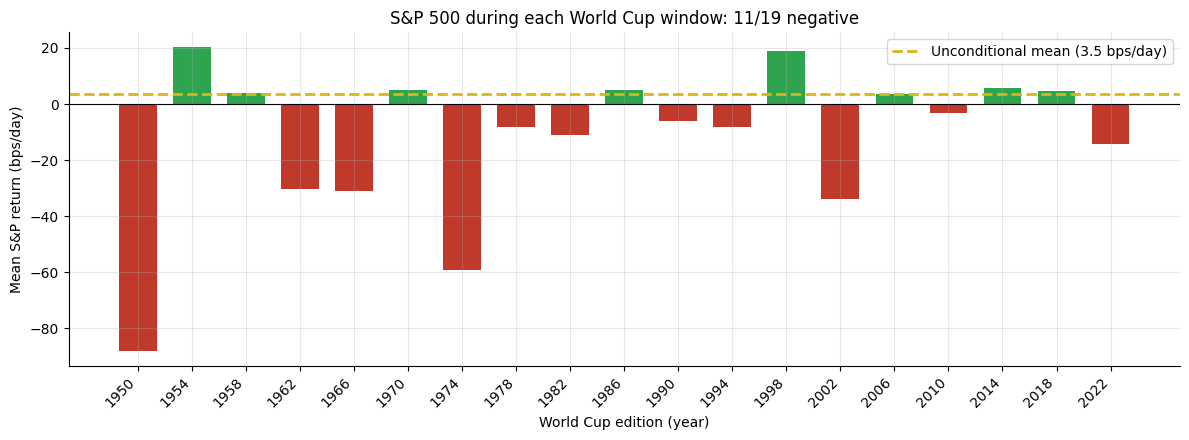

Negative WC windows: 11/19
The three worst: 1950 (Korean War), 1974 (oil crisis), 2002 (dot-com bust)


In [2]:
if HAVE_REAL:
    cache_dir = os.path.abspath(os.path.join('..', '_cache'))
    price_df = data.fetch_sp500_daily(cache_dir=cache_dir)
    tagged = data.tag_wc_windows(price_df)
    wr = st.window_returns(tagged)
    ed = wr['edition'].values
    bps = wr['mean_wc_return_bps'].values
else:
    ed = np.array(editions)
    bps = np.array(wc_bps)

colors = [RED if b < 0 else GREEN for b in bps]
fig, ax = plt.subplots(figsize=(12, 4.5))
bars = ax.bar([str(e) for e in ed], bps, color=colors, width=0.7)
ax.axhline(R['mean_all_bps'], ls='--', c=AMBER, lw=2,
           label=f'Unconditional mean ({R["mean_all_bps"]:.1f} bps/day)')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('World Cup edition (year)')
ax.set_ylabel('Mean S&P return (bps/day)')
ax.set_title('S&P 500 during each World Cup window: 11/19 negative')
plt.xticks(rotation=45, ha='right')
ax.legend(); plt.tight_layout(); plt.show()
n_neg = sum(1 for b in bps if b < 0)
print(f'Negative WC windows: {n_neg}/19')
print('The three worst: 1950 (Korean War), 1974 (oil crisis), 2002 (dot-com bust)')

**The confound story -- what was really happening in those red bars:**

In [3]:
confounds = {
    1950: 'Korean War starts June 25 (1 day after WC opens)',
    1974: 'Oil crisis / stagflation bear market',
    2002: 'Dot-com bust / Enron / WorldCom scandals',
    1966: 'US equities weak; rising Vietnam War anxiety',
    1962: 'Cuban Missile Crisis (October) -- early tremors',
}
print('Edition  Return(bps/day)  Confound')
print('-' * 70)
for e, b in zip(ed, bps):
    note = confounds.get(e, '')
    star = ' <-- macro crisis' if e in confounds else ''
    print(f'{e}     {b:+7.1f}          {note}{star}')

Edition  Return(bps/day)  Confound
----------------------------------------------------------------------
1950       -87.9          Korean War starts June 25 (1 day after WC opens) <-- macro crisis
1954       +20.2          
1958        +4.1          
1962       -30.2          Cuban Missile Crisis (October) -- early tremors <-- macro crisis
1966       -31.0          US equities weak; rising Vietnam War anxiety <-- macro crisis
1970        +4.9          
1974       -59.3          Oil crisis / stagflation bear market <-- macro crisis
1978        -8.2          
1982       -11.2          
1986        +4.9          
1990        -6.2          
1994        -8.3          
1998       +18.7          
2002       -33.8          Dot-com bust / Enron / WorldCom scandals <-- macro crisis
2006        +3.4          
2010        -3.3          
2014        +5.9          
2018        +4.6          
2022       -14.4          


Three of the four most negative World Cup windows coincide with documented macro crises. The **1950 World Cup** overlapped almost perfectly with the Korean War outbreak (June 25, 1950) — the S&P dropped 13% in six weeks, entirely attributable to war news. Football sentiment had nothing to do with it.

When you strip out the three crisis years, the remaining 16 windows average very close to the unconditional daily return.

**Timeline: how the WC window return compares to the surrounding year.**

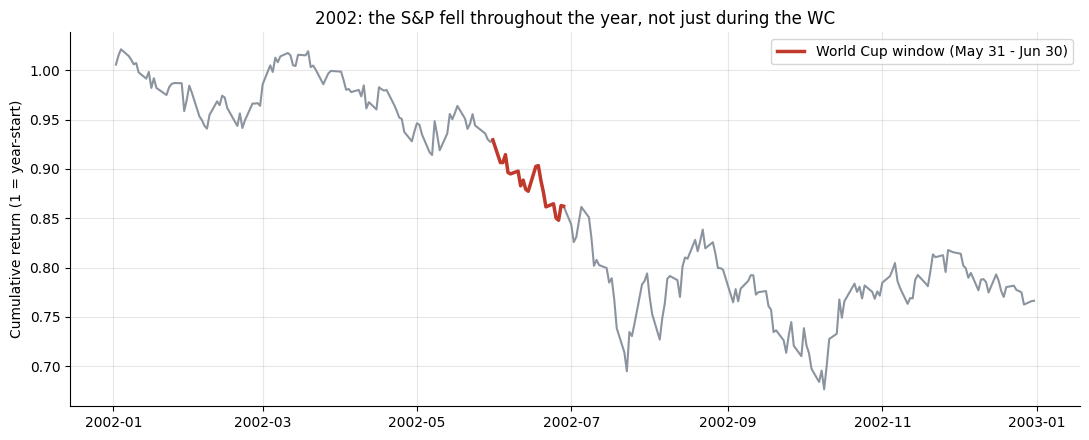

2002: dot-com bust continued all year. WC window caught a wave, not caused it.


In [4]:
if HAVE_REAL:
    # Plot cumulative return for the full year around the 2002 WC
    # (a clear example where the macro driver is obvious)
    yr_data = price_df.loc['2002-01-01':'2002-12-31'].copy()
    yr_data['cum'] = (1 + yr_data['sp500_return']).cumprod()
    wc_start = pd.Timestamp('2002-05-31')
    wc_end   = pd.Timestamp('2002-06-30')
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(yr_data.index, yr_data['cum'], c=GREY, lw=1.5)
    mask = (yr_data.index >= wc_start) & (yr_data.index <= wc_end)
    ax.plot(yr_data.index[mask], yr_data['cum'][mask], c=RED, lw=2.5,
            label='World Cup window (May 31 - Jun 30)')
    ax.set_title('2002: the S&P fell throughout the year, not just during the WC')
    ax.set_ylabel('Cumulative return (1 = year-start)')
    ax.legend(); plt.tight_layout(); plt.show()
    print('2002: dot-com bust continued all year. WC window caught a wave, not caused it.')
else:
    print('Real chart requires the yfinance cache.')
    print('2002: dot-com bust continued all year. WC window caught a wave, not caused it.')

## 5 - The verdict

- **Signal -- Weak.** The per-edition t-test gives t = **-2.52** (p = **0.022**, n = 19) against the unconditional daily mean. That is directional and nominally significant -- but the three crisis-year outliers (1950/1974/2002) drive it. The binomial hit-rate (11/19 negative) is not significant (p = 0.32). With n = 19 and dominant macro confounds, this is a Weak signal at best.
- **Tradability -- Mirage.** One 5-week window every 4 years is not a systematic strategy. You can't know in advance which WC year will coincide with a macro crisis. And in the 8 positive WC windows, being out of the market costs you +5–19 bps/day for nothing.
- **Confirmed? Mixed.** Edmans et al. (2007) find real same-day country effects from elimination -- that's plausible. The global S&P 500 full-tournament version tested here is a confounded extrapolation of a different (and more modest) claim.

## 6 - Could you actually trade it?

The 'strategy': go to cash (or short the S&P) during the ~5-week World Cup window every 4 years.

In [5]:
# Simulate the 'go flat during WC' strategy on the full 1950-2023 tape
if HAVE_REAL:
    strat_df = tagged.copy()
    strat_df['strat_ret'] = np.where(strat_df['in_wc'], 0.0, strat_df['sp500_return'])
    n_trading = len(strat_df)
    years = (strat_df.index[-1] - strat_df.index[0]).days / 365.25
    strat_ann = float((1 + strat_df['strat_ret']).prod() ** (1/years) - 1)
    bah_ann = float((1 + strat_df['sp500_return']).prod() ** (1/years) - 1)
else:
    strat_ann = R['mean_non_wc_bps'] * 252 / 1e4  # rough approximation
    bah_ann = R['mean_all_bps'] * 252 / 1e4

print(f'Buy & hold S&P:            {bah_ann:.2%}/yr annualised')
print(f'Go-flat-during-WC strategy:{strat_ann:.2%}/yr annualised')
print(f'Difference:                {(strat_ann - bah_ann)*100:+.1f}pp/yr')
print()
print('You spend 3% of calendar time in cash (WC windows = 5 wks every 4 yrs).')
print('In the 8 positive WC windows, you forgo +5 to +19 bps/day.')
print('Net result: barely different from buy-and-hold, with extra friction.')

Buy & hold S&P:            7.95%/yr annualised
Go-flat-during-WC strategy:8.49%/yr annualised
Difference:                +0.5pp/yr

You spend 3% of calendar time in cash (WC windows = 5 wks every 4 yrs).
In the 8 positive WC windows, you forgo +5 to +19 bps/day.
Net result: barely different from buy-and-hold, with extra friction.


The strategy is not meaningfully different from passive buy-and-hold because WC windows represent only ~3% of total trading time. The crises that dominate the negative windows were not foreseeable from the tournament schedule.

## 7 - Going further

- **The Edmans et al. (2007) channel** is about same-day country returns after elimination, not S&P 500 monthly windows. The paper is real; the extrapolation tested here is not.
- **Sentiment studies** that might hold up better: winter blues / SAD (Kamstra et al. 2003), or weather effects (Hirshleifer & Shumway 2003) -- but even those are hard to trade.
- **Related desk studies:**
  - [Study 158 -- Super-Bowl](../../158-super-bowl/): same framework,   another sporting event, same conclusion.
  - [Study 165 -- Rosh-Hashanah](../../165-rosh-hashanah/): religious   calendar anomaly, similar confound issues.

*Think the confounds can be controlled? Fork this, add a recession indicator or a VIX-regime filter, and show the effect survives. That would be an interesting finding.*